# Telco Customer Churn Analysis — End-to-End Internship Project

This notebook runs the **tested source-of-truth analysis script**. The script is path-safe, generates the executive dashboard, charts, statistical test tables, model metrics and customer risk scores, and documents limitations.

**Business focus:** identify churn patterns, retention drivers, lifecycle trends and actionable retention priorities.

## 1. Reproducible workflow

`Data → Quality Audit → Cleaning → Lifecycle/Segment Analysis → Statistical Testing → Logistic Regression → Risk Scoring → Business Recommendations`

In [1]:
%run ../src/telco_customer_churn_analysis.py

Rows: 7,043
Columns: 21
Duplicate rows: 0
Unique customer IDs: 7,043



=== PROJECT SUMMARY ===
Customers: 7,043
Churned: 1,869 (26.5%)
Retained: 5,174 (73.5%)
Average tenure: 32.4 months
Average monthly charges: $64.76
Historical monthly charges associated with churned customers: $139,130.85
Model ROC-AUC: 0.845
Model recall: 0.805
Outputs: /tmp/fds2/telco-customer-churn-analysis-github-ready/outputs


<Figure size 900x500 with 0 Axes>

<Figure size 900x500 with 0 Axes>

## 2. Executive dashboard

The generated dashboard is saved at `../outputs/executive_dashboard.png`.

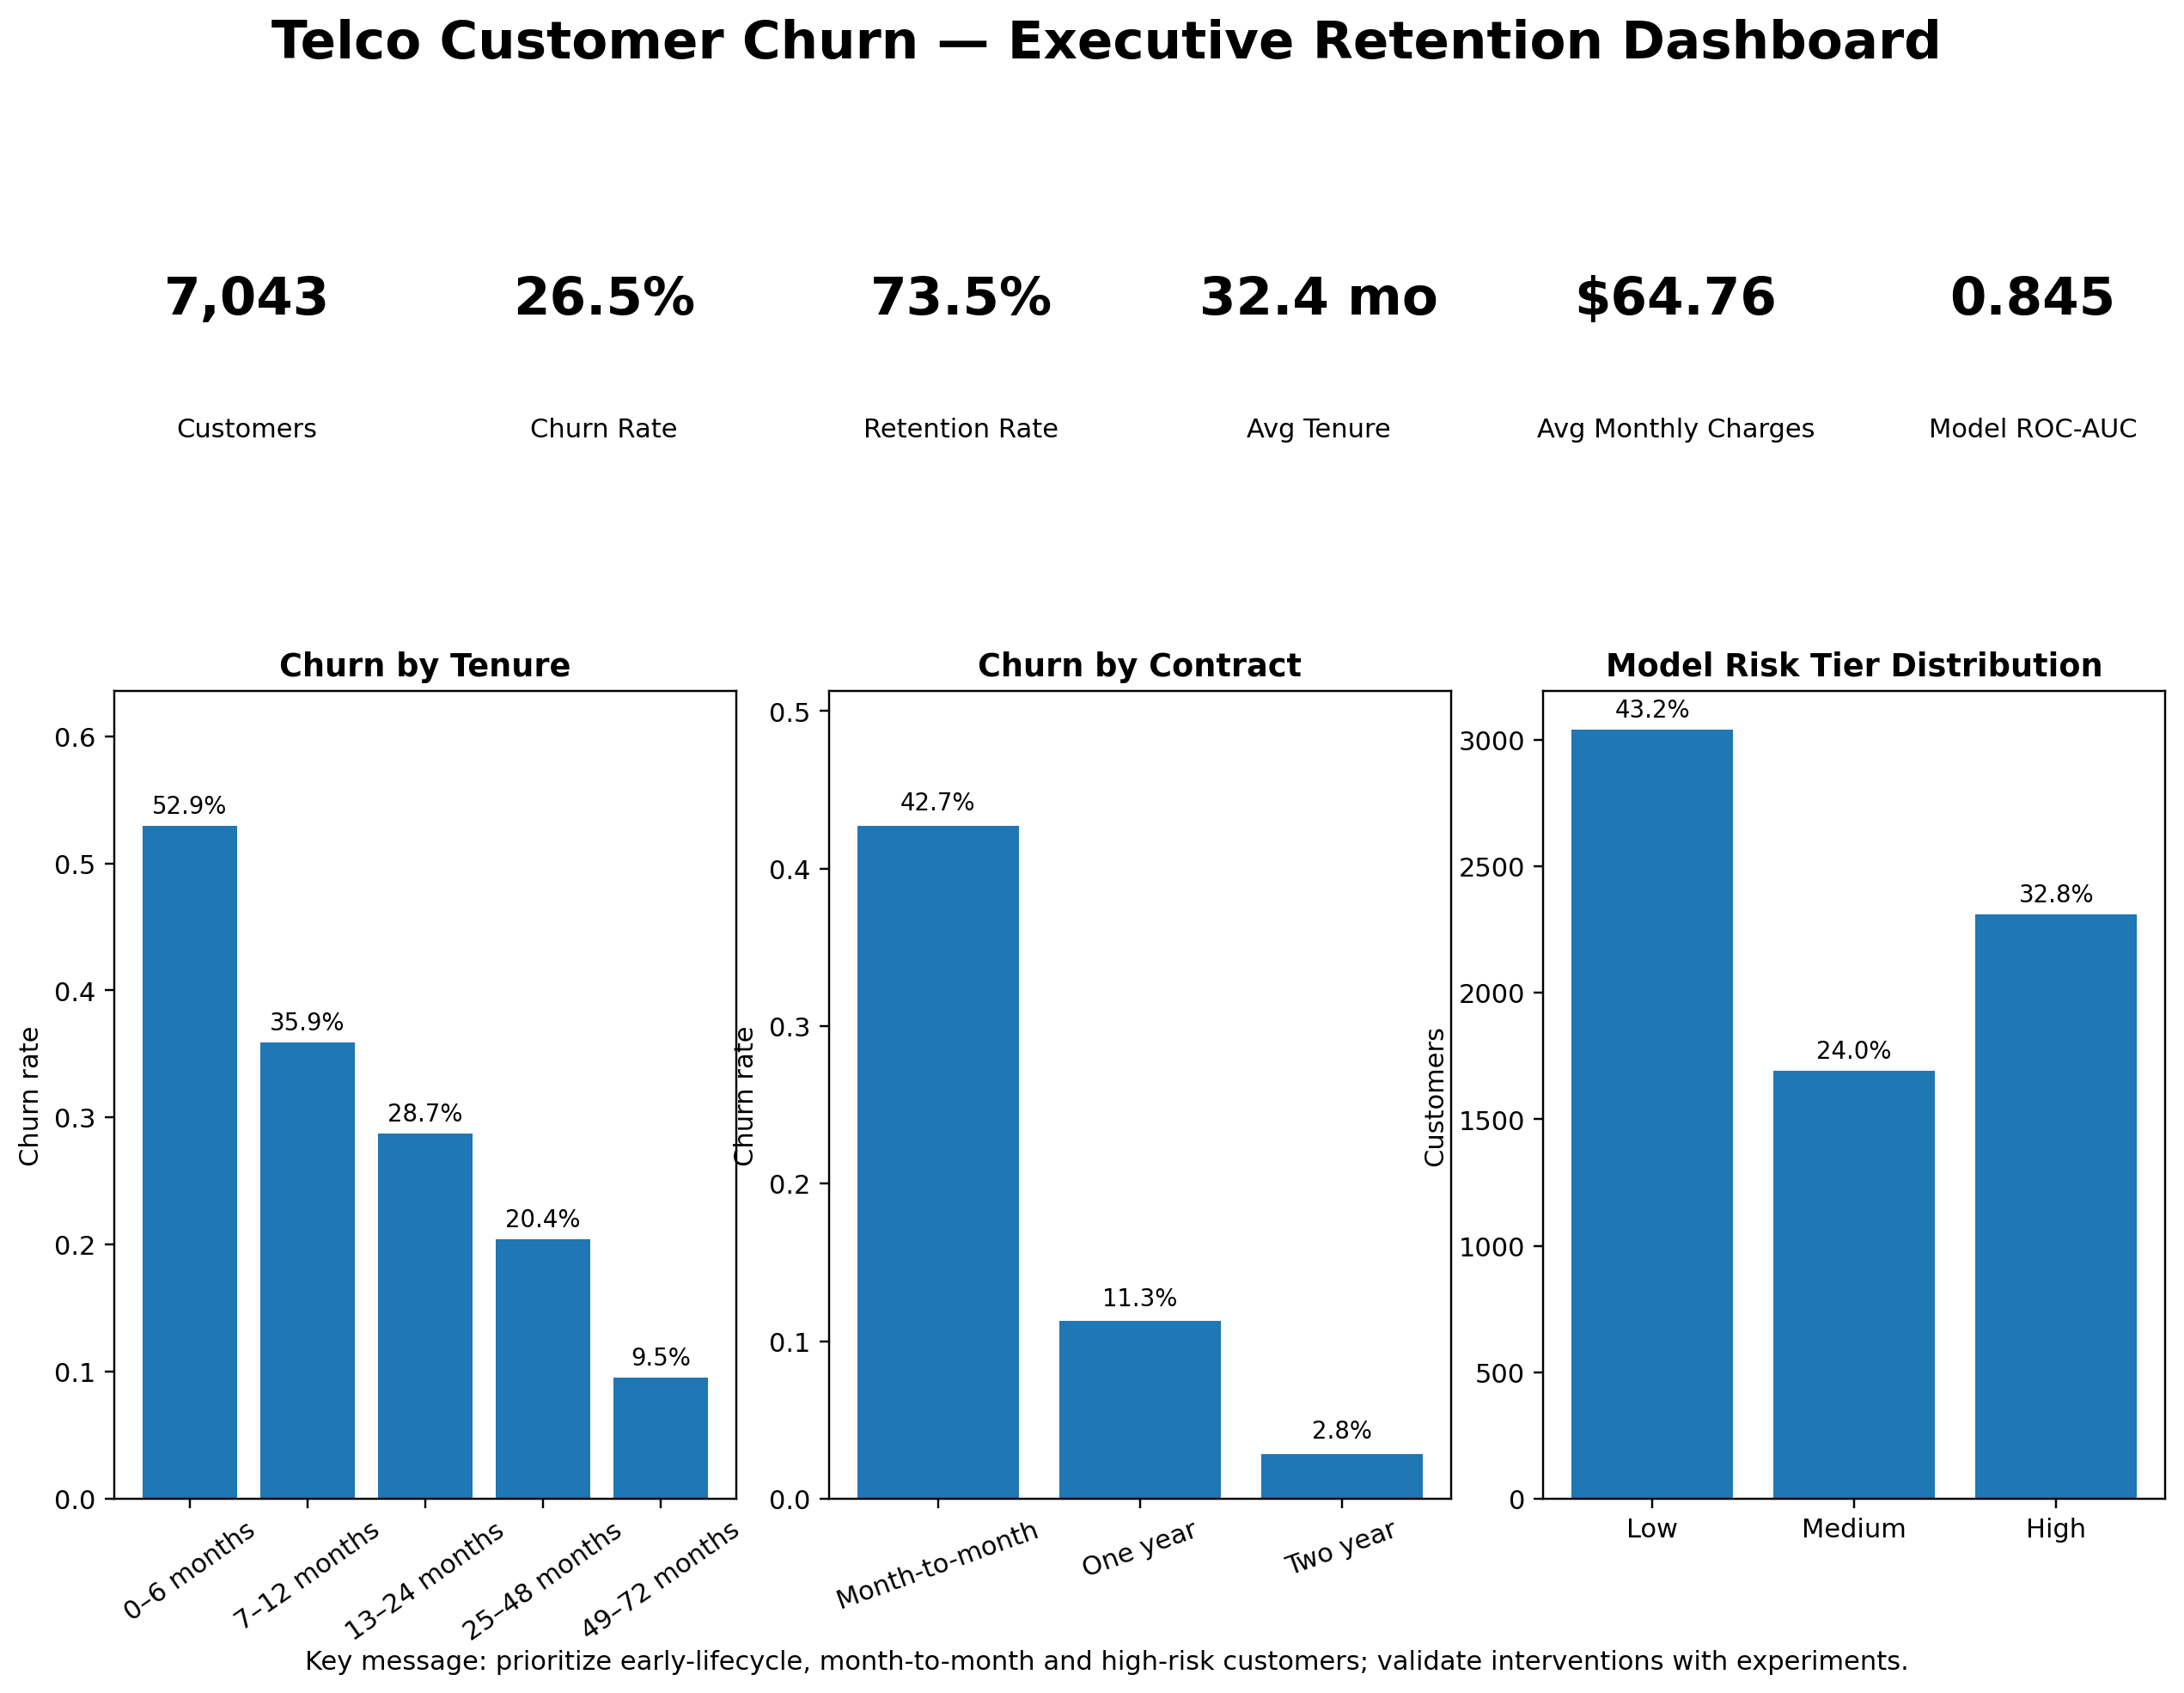

In [2]:
from IPython.display import Image, display
display(Image(filename='../outputs/executive_dashboard.png'))

## 3. Key output tables

The complete results are stored under `../outputs/tables/`.

In [3]:
import pandas as pd
from pathlib import Path
base=Path('../outputs/tables')
print('Model metrics')
display(pd.read_csv(base/'model_metrics.csv'))
print('Risk tiers')
display(pd.read_csv(base/'risk_tier_summary.csv'))
print('Chi-square results')
display(pd.read_csv(base/'chi_square_results.csv').head(10))

Model metrics


,Metric,Value
0,Accuracy,0.74
1,Precision,0.51
2,Recall,0.80
3,F1,0.62
4,ROC-AUC,0.85


Risk tiers


,RiskTier,Customers,Share
0,Low,3040,0.43
1,Medium,1693,0.24
2,High,2310,0.33


Chi-square results


,Feature,Chi2,p_value,Significant_at_5pct,BH_adjusted_p,Significant_after_BH
0,Contract,"1,184.60",0.00,True,0.00,True
1,OnlineSecurity,850.00,0.00,True,0.00,True
2,TechSupport,828.20,0.00,True,0.00,True
3,InternetService,732.31,0.00,True,0.00,True
4,PaymentMethod,648.14,0.00,True,0.00,True
5,OnlineBackup,601.81,0.00,True,0.00,True
6,DeviceProtection,558.42,0.00,True,0.00,True
7,StreamingMovies,375.66,0.00,True,0.00,True
8,StreamingTV,374.20,0.00,True,0.00,True
9,PaperlessBilling,258.28,0.00,True,0.00,True


## 4. Interpretation

- Early-tenure customers have the highest observed churn.
- Month-to-month contracts have substantially higher observed churn than longer contracts.
- Statistical tests identify associations; they do not establish causality.
- The model is evaluated on a holdout set before being refit on all historical records for final portfolio scoring.
- The dataset has no signup date or explicit churn reason, so true calendar cohorts and stated churn reasons are not claimed.